Upload: models_catalog.csv, pricing_history.csv, capability_milestones.csv, compute_estimates.csv, benchmark_scores.csv


Saving benchmark_scores.csv to benchmark_scores (6).csv
Saving capability_milestones.csv to capability_milestones (4).csv
Saving compute_estimates.csv to compute_estimates (5).csv
Saving models_catalog.csv to models_catalog (5).csv
Saving pricing_history.csv to pricing_history (3).csv
models: (113, 13)
pricing: (1187, 5)
milestones: (57, 13)
compute: (113, 11)
benchmarks: (1276, 9)
MODELS CATALOG OVERVIEW
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 113 entries, 0 to 112
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   model_id                 113 non-null    object 
 1   model_name               113 non-null    object 
 2   organization             113 non-null    object 
 3   release_date             113 non-null    object 
 4   release_year             113 non-null    int64  
 5   release_month            113 non-null    int64  
 6   params_billions          113 non-null    float64


,count,mean,std,min,25%,50%,75%,max
release_year,113.0,2023.592920,1.618184,2020.0,2023.0,2024.0,2025.0,2026.0
release_month,113.0,6.265487,3.354149,1.0,3.0,6.0,9.0,12.0
params_billions,113.0,376.700000,530.039713,1.6,70.0,175.0,500.0,3000.0
active_params_billions,113.0,300.768142,469.178761,1.6,62.2,137.0,325.9,3000.0
context_window_k_tokens,113.0,162.371681,338.184602,2.0,16.0,64.0,200.0,2000.0


/tmp/ipykernel_1154/1759124362.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=models, x='release_year', ax=axes[0], palette='viridis')


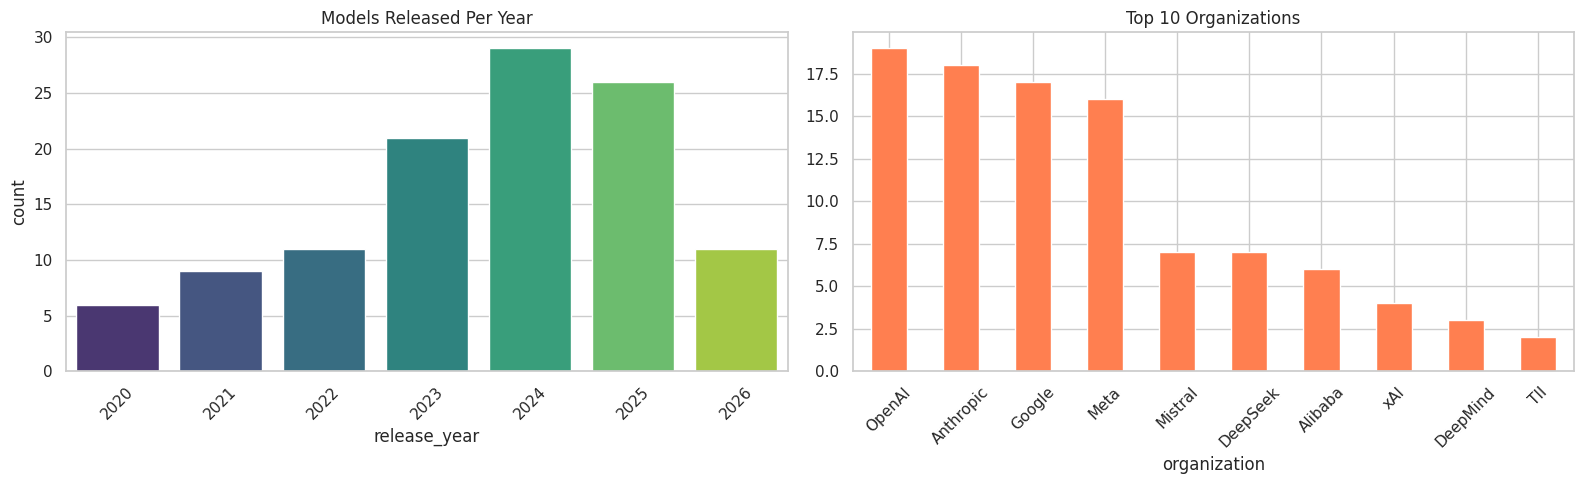

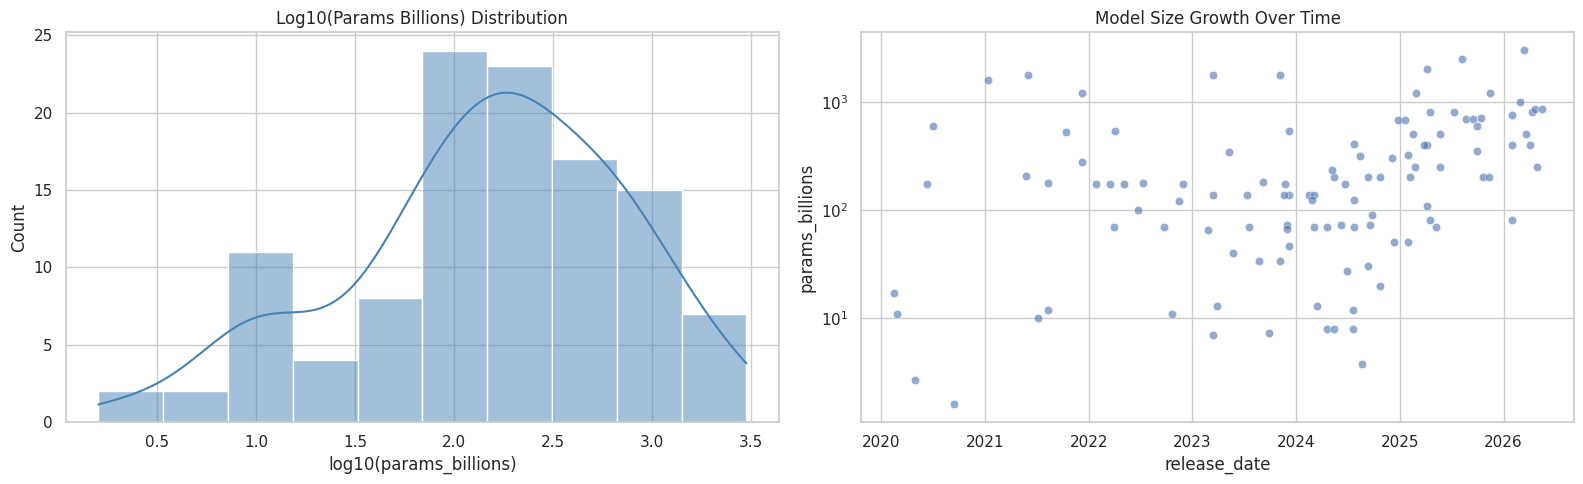

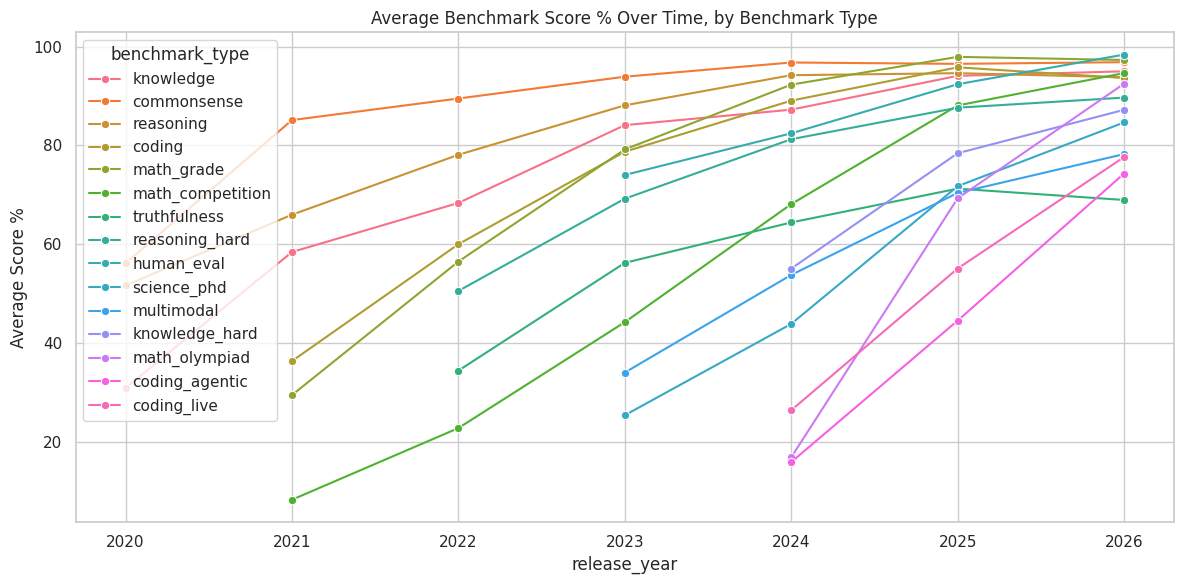

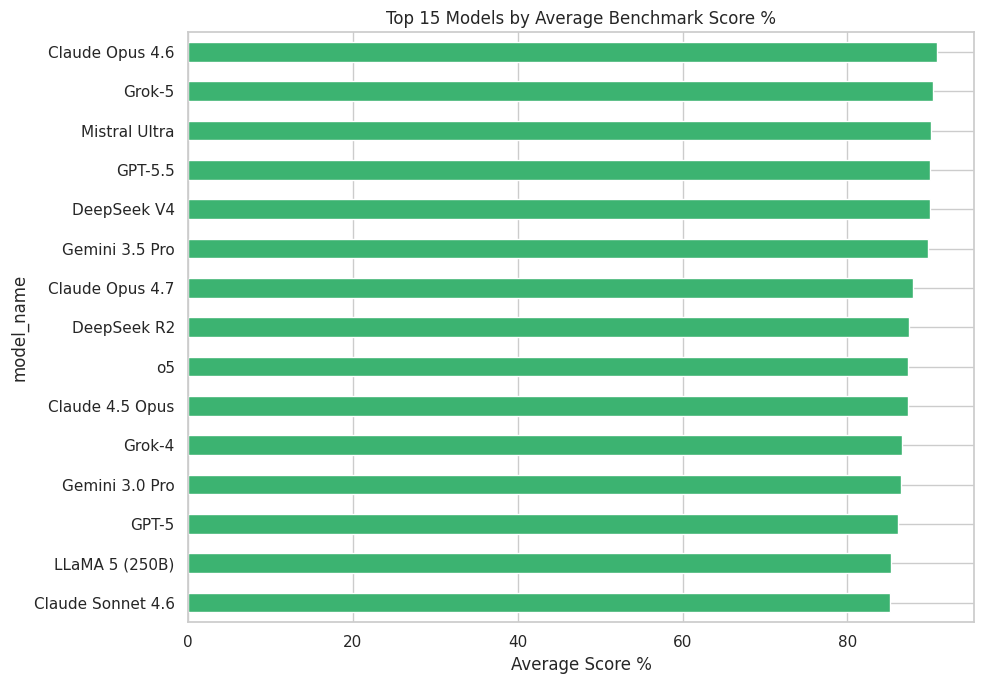

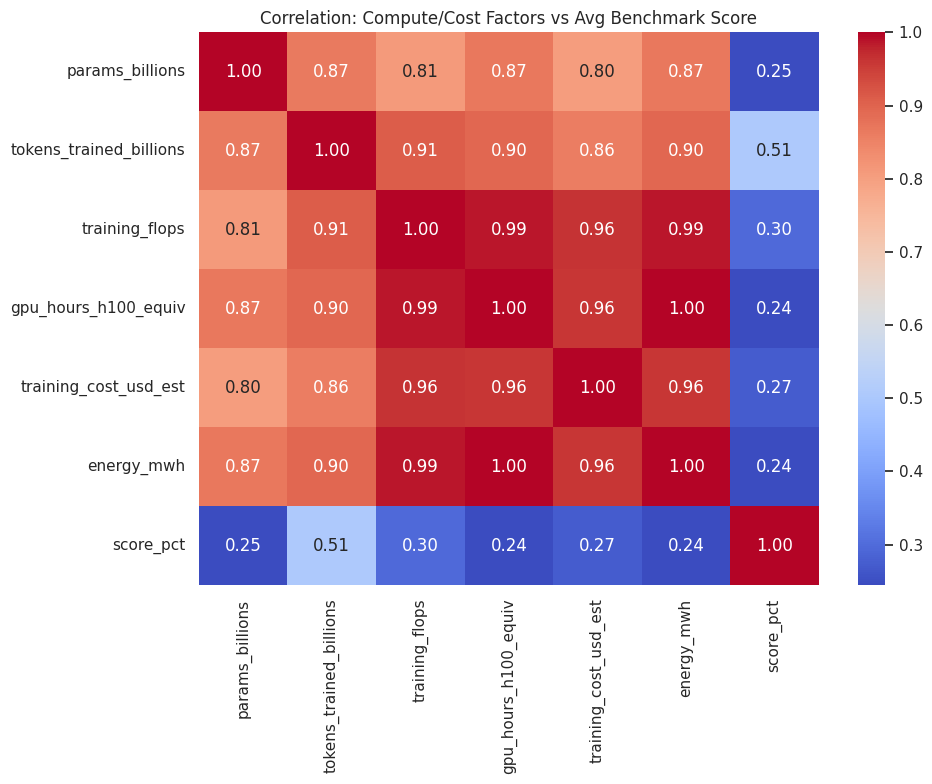

TOP CORRELATED FACTOR PAIRS


,Feature 1,Feature 2,Correlation
0,energy_mwh,gpu_hours_h100_equiv,1.000000
1,training_flops,gpu_hours_h100_equiv,0.987624
2,training_flops,energy_mwh,0.987624
3,training_cost_usd_est,training_flops,0.961660
4,gpu_hours_h100_equiv,training_cost_usd_est,0.961470
5,training_cost_usd_est,energy_mwh,0.961470
6,training_flops,tokens_trained_billions,0.910704
7,energy_mwh,tokens_trained_billions,0.896306
8,tokens_trained_billions,gpu_hours_h100_equiv,0.896305
9,energy_mwh,params_billions,0.867883


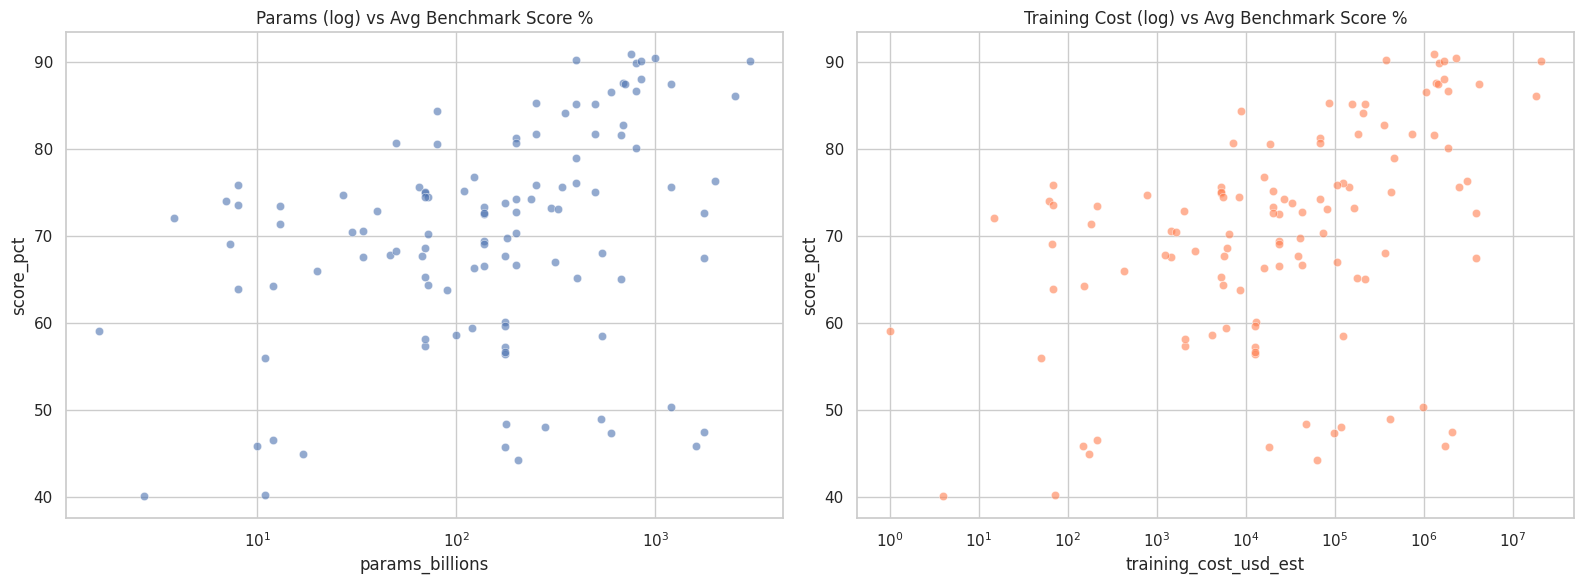

/tmp/ipykernel_1154/1759124362.py:140: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=milestones, x='year', palette='magma')


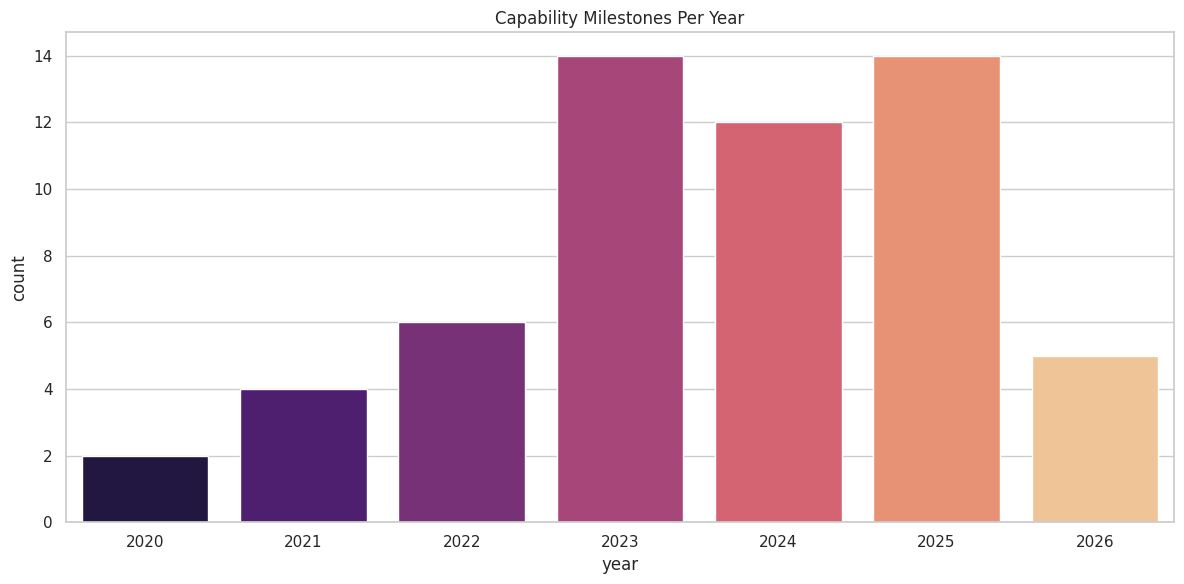

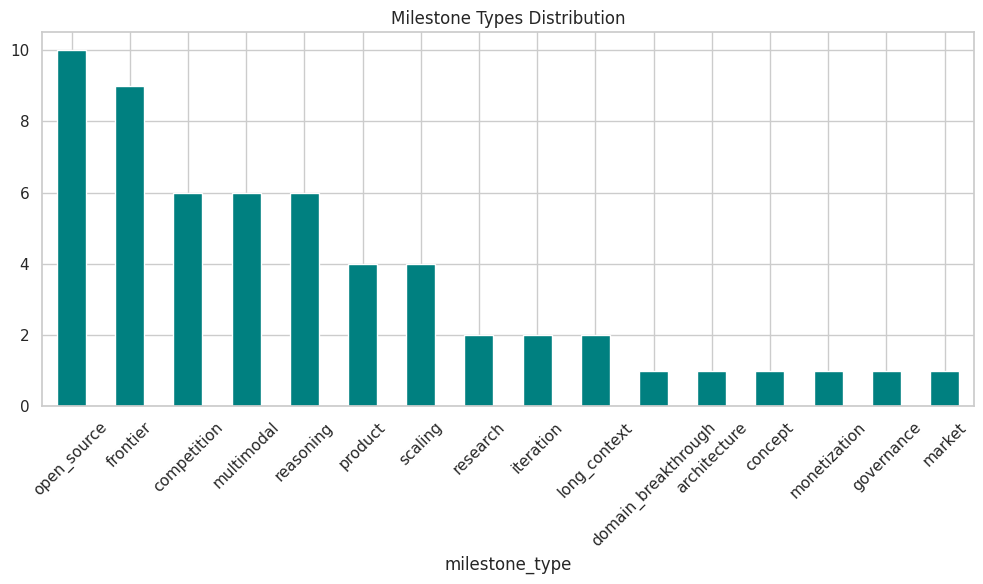

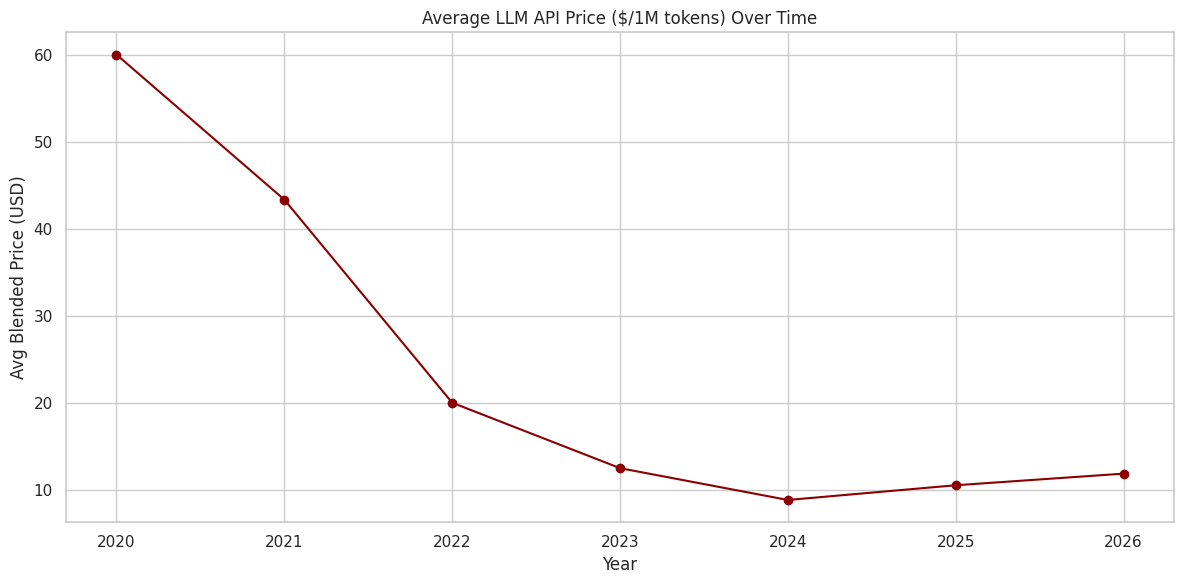

Outlier counts: {'params_billions': 10, 'context_window_k_tokens': 5}


/tmp/ipykernel_1154/1759124362.py:178: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=models, x='release_year', ax=axes[0, 0], palette='viridis')


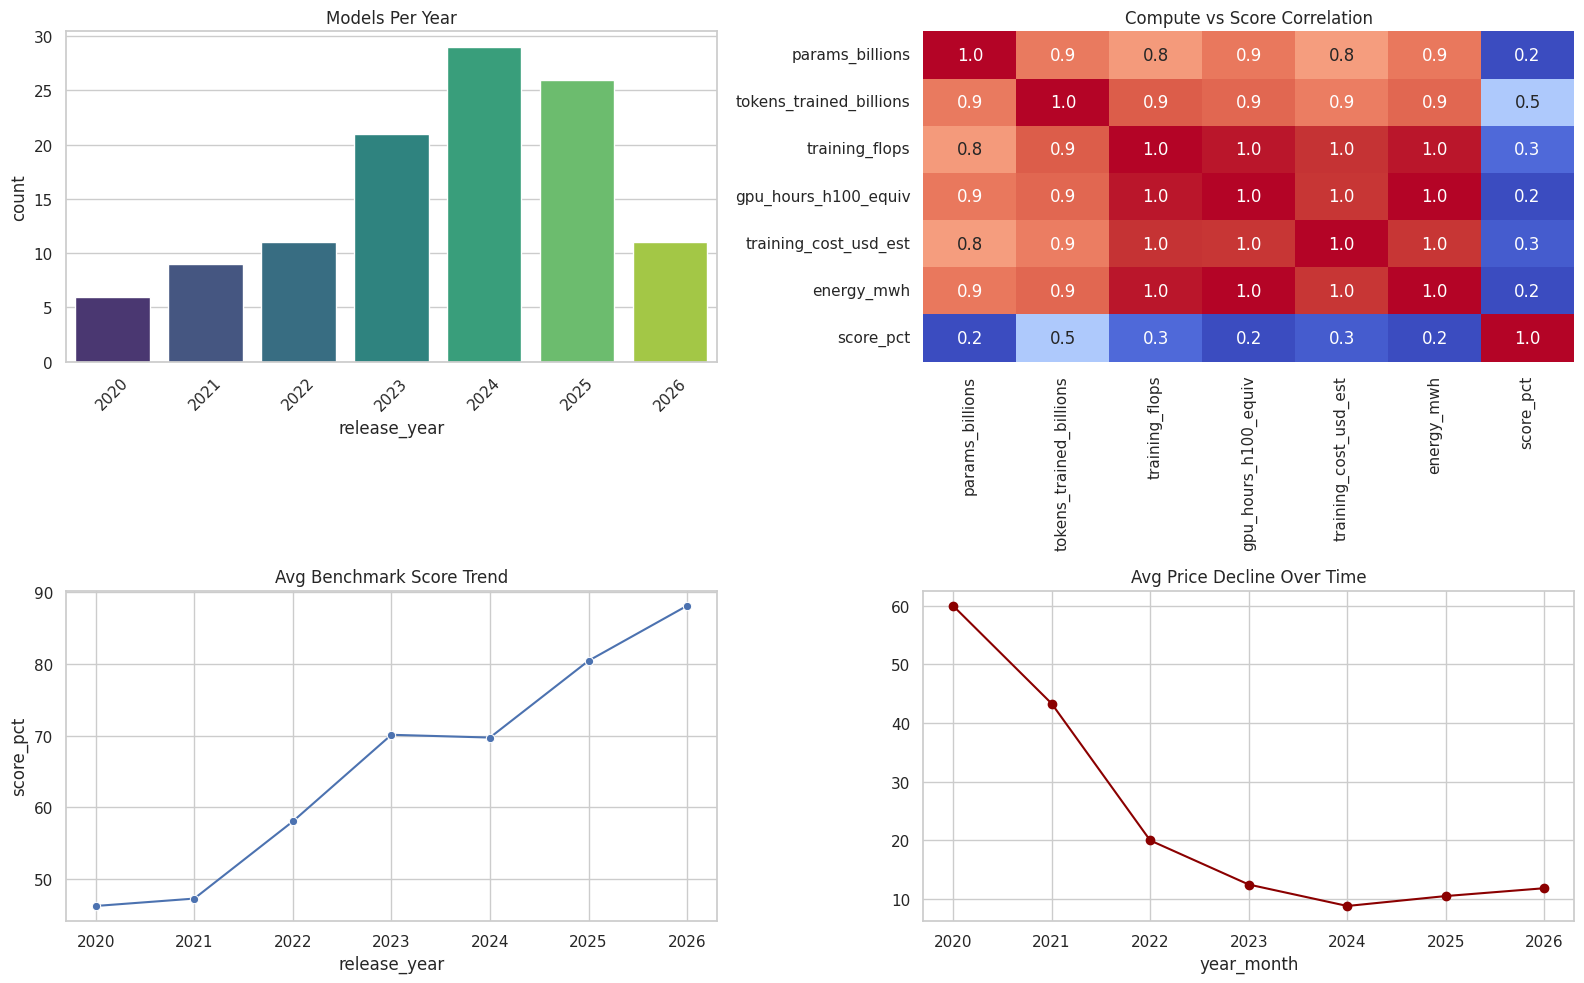

EDA INSIGHTS REPORT — LLM BENCHMARKS & CAPABILITIES

1. DATASET: 113 models, 1276 benchmark records, 57 milestones

2. GROWTH: Models released per year rising from 6 in 2020 to 11 in 2026

3. TOP ORG: OpenAI has released the most models (19)

4. TOP MODEL BY AVG SCORE: Claude Opus 4.6 (90.8%)

5. KEY CORRELATIONS:
   - energy_mwh & gpu_hours_h100_equiv: strong (1.00)
   - training_flops & gpu_hours_h100_equiv: strong (0.99)
   - training_flops & energy_mwh: strong (0.99)
   - training_cost_usd_est & training_flops: strong (0.96)
   - gpu_hours_h100_equiv & training_cost_usd_est: strong (0.96)

6. PRICING: Avg cost moved from $60.00 to $11.85 per 1M tokens (2020–2026)



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Task 3 Complete: Full EDA performed across all 5 LLM dataset files.


In [7]:
# ===================================================
# TASK 3: EXPLORATORY DATA ANALYSIS (EDA)
# Dataset: LLM Benchmarks & Capabilities
# ===================================================

# %% Step 1: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# %% Step 2: Upload All 5 Files
from google.colab import files
print("Upload: models_catalog.csv, pricing_history.csv, capability_milestones.csv, compute_estimates.csv, benchmark_scores.csv")
uploaded = files.upload()

# %% Step 3: Load Datasets
models = pd.read_csv("models_catalog.csv")
pricing = pd.read_csv("pricing_history.csv")
milestones = pd.read_csv("capability_milestones.csv")
compute = pd.read_csv("compute_estimates.csv")
benchmarks = pd.read_csv("benchmark_scores.csv")

for name, d in [("models", models), ("pricing", pricing), ("milestones", milestones),
                ("compute", compute), ("benchmarks", benchmarks)]:
    print(f"{name}: {d.shape}")

# %% Step 4: Dataset Overview
print("="*60)
print("MODELS CATALOG OVERVIEW")
print("="*60)
models.info()
display(models.describe().T)

# %% Step 5: Clean (drop dupes, parse dates)
models = models.drop_duplicates()
models['release_date'] = pd.to_datetime(models['release_date'])
compute['release_date'] = pd.to_datetime(compute['release_date'])
benchmarks['release_date'] = pd.to_datetime(benchmarks['release_date'])
milestones['date'] = pd.to_datetime(milestones['date'])
pricing['year_month'] = pd.to_datetime(pricing['year_month'])

# %% Step 6: Models Per Year & Organization
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.countplot(data=models, x='release_year', ax=axes[0], palette='viridis')
axes[0].set_title("Models Released Per Year")
axes[0].tick_params(axis='x', rotation=45)

models['organization'].value_counts().head(10).plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title("Top 10 Organizations")
axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig("models_year_org.png", dpi=300)
plt.show()

# %% Step 7: Parameter Count Distribution & Growth
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.histplot(np.log10(models['params_billions']), kde=True, ax=axes[0], color='steelblue')
axes[0].set_title("Log10(Params Billions) Distribution")
axes[0].set_xlabel("log10(params_billions)")

sns.scatterplot(data=models, x='release_date', y='params_billions', ax=axes[1], alpha=0.6)
axes[1].set_yscale('log')
axes[1].set_title("Model Size Growth Over Time")
plt.tight_layout()
plt.savefig("params_distribution_growth.png", dpi=300)
plt.show()

# %% Step 8: Benchmark Score Trends Over Time
bench_merged = benchmarks.merge(models[['model_id', 'release_year']], on='model_id', how='left')

plt.figure(figsize=(12, 6))
sns.lineplot(data=bench_merged, x='release_year', y='score_pct', hue='benchmark_type', estimator='mean', errorbar=None, marker='o')
plt.title("Average Benchmark Score % Over Time, by Benchmark Type")
plt.ylabel("Average Score %")
plt.tight_layout()
plt.savefig("benchmark_trends.png", dpi=300)
plt.show()

# %% Step 9: Top Models by Average Benchmark Score
top_models = bench_merged.groupby('model_name')['score_pct'].mean().sort_values(ascending=False).head(15)
plt.figure(figsize=(10, 7))
top_models.plot(kind='barh', color='mediumseagreen')
plt.title("Top 15 Models by Average Benchmark Score %")
plt.xlabel("Average Score %")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("top_models_score.png", dpi=300)
plt.show()

# %% Step 10: Correlation Analysis - Compute vs Capability
corr_df = compute.merge(
    bench_merged.groupby('model_id')['score_pct'].mean().reset_index(),
    on='model_id', how='inner'
)
num_corr_cols = ['params_billions', 'tokens_trained_billions', 'training_flops',
                  'gpu_hours_h100_equiv', 'training_cost_usd_est', 'energy_mwh', 'score_pct']

corr_matrix = corr_df[num_corr_cols].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation: Compute/Cost Factors vs Avg Benchmark Score")
plt.tight_layout()
plt.savefig("correlation_heatmap.png", dpi=300)
plt.show()

# %% Step 11: Identify Top Correlated Pairs (Key Influencing Factors)
corr_pairs = corr_matrix.unstack().sort_values(ascending=False)
corr_pairs = corr_pairs[corr_pairs != 1.0]
seen, top_pairs = set(), []
for (a, b), val in corr_pairs.items():
    if (b, a) not in seen:
        seen.add((a, b))
        top_pairs.append((a, b, val))
top_pairs_df = pd.DataFrame(top_pairs, columns=["Feature 1", "Feature 2", "Correlation"])
top_pairs_df = top_pairs_df.sort_values(by="Correlation", key=abs, ascending=False).head(10)
print("="*60)
print("TOP CORRELATED FACTOR PAIRS")
print("="*60)
display(top_pairs_df)

# %% Step 12: Scatter Plots for Compute vs Score (Key Relationships)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.scatterplot(data=corr_df, x='params_billions', y='score_pct', ax=axes[0], alpha=0.6)
axes[0].set_xscale('log')
axes[0].set_title("Params (log) vs Avg Benchmark Score %")

sns.scatterplot(data=corr_df, x='training_cost_usd_est', y='score_pct', ax=axes[1], alpha=0.6, color='coral')
axes[1].set_xscale('log')
axes[1].set_title("Training Cost (log) vs Avg Benchmark Score %")
plt.tight_layout()
plt.savefig("compute_vs_score.png", dpi=300)
plt.show()

# %% Step 13: Capability Milestones Analysis
plt.figure(figsize=(12, 6))
sns.countplot(data=milestones, x='year', palette='magma')
plt.title("Capability Milestones Per Year")
plt.tight_layout()
plt.savefig("milestones_per_year.png", dpi=300)
plt.show()

plt.figure(figsize=(10, 6))
milestones['milestone_type'].value_counts().plot(kind='bar', color='teal')
plt.title("Milestone Types Distribution")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("milestone_types.png", dpi=300)
plt.show()

# %% Step 14: Pricing Trends - Cost Decline Over Time
plt.figure(figsize=(12, 6))
yearly_avg_price = pricing.groupby(pricing['year_month'].dt.year)['blended_usd_per_1m_tokens'].mean()
yearly_avg_price.plot(kind='line', marker='o', color='darkred')
plt.title("Average LLM API Price ($/1M tokens) Over Time")
plt.xlabel("Year")
plt.ylabel("Avg Blended Price (USD)")
plt.tight_layout()
plt.savefig("pricing_decline.png", dpi=300)
plt.show()

# %% Step 15: Outlier Summary Across Key Numeric Columns
outlier_summary = {}
for col in ['params_billions', 'context_window_k_tokens']:
    Q1, Q3 = models[col].quantile(0.25), models[col].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    outlier_summary[col] = len(models[(models[col] < lower) | (models[col] > upper)])

print("Outlier counts:", outlier_summary)

# %% Step 16: Combined EDA Dashboard
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

sns.countplot(data=models, x='release_year', ax=axes[0, 0], palette='viridis')
axes[0, 0].set_title("Models Per Year")
axes[0, 0].tick_params(axis='x', rotation=45)

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".1f", ax=axes[0, 1], cbar=False)
axes[0, 1].set_title("Compute vs Score Correlation")

sns.lineplot(data=bench_merged, x='release_year', y='score_pct', estimator='mean', errorbar=None, marker='o', ax=axes[1, 0])
axes[1, 0].set_title("Avg Benchmark Score Trend")

yearly_avg_price.plot(kind='line', marker='o', ax=axes[1, 1], color='darkred')
axes[1, 1].set_title("Avg Price Decline Over Time")

plt.tight_layout()
plt.savefig("eda_dashboard.png", dpi=300)
plt.show()

# %% Step 17: Insights Report
print("="*70)
print("EDA INSIGHTS REPORT — LLM BENCHMARKS & CAPABILITIES")
print("="*70)
print(f"\n1. DATASET: {models.shape[0]} models, {benchmarks.shape[0]} benchmark records, {milestones.shape[0]} milestones")
print(f"\n2. GROWTH: Models released per year rising from {models[models.release_year==models.release_year.min()].shape[0]} "
      f"in {models.release_year.min()} to {models[models.release_year==models.release_year.max()].shape[0]} in {models.release_year.max()}")
print(f"\n3. TOP ORG: {models['organization'].value_counts().idxmax()} has released the most models "
      f"({models['organization'].value_counts().max()})")
print(f"\n4. TOP MODEL BY AVG SCORE: {top_models.idxmax()} ({top_models.max():.1f}%)")
print(f"\n5. KEY CORRELATIONS:")
for _, row in top_pairs_df.head(5).iterrows():
    strength = "strong" if abs(row['Correlation']) > 0.7 else "moderate" if abs(row['Correlation']) > 0.4 else "weak"
    print(f"   - {row['Feature 1']} & {row['Feature 2']}: {strength} ({row['Correlation']:.2f})")
print(f"\n6. PRICING: Avg cost moved from ${yearly_avg_price.iloc[0]:.2f} to ${yearly_avg_price.iloc[-1]:.2f} per 1M tokens "
      f"({yearly_avg_price.index.min()}–{yearly_avg_price.index.max()})")
print("\n" + "="*70)

# %% Step 18: Download Outputs
files.download("eda_dashboard.png")
files.download("correlation_heatmap.png")
files.download("benchmark_trends.png")
files.download("pricing_decline.png")

print("Task 3 Complete: Full EDA performed across all 5 LLM dataset files.")